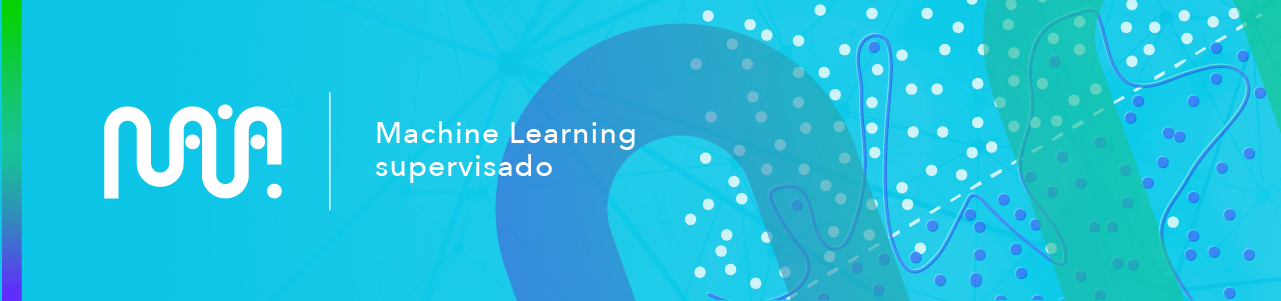
# Taller semana 2: Dependencia de los datos de entrenamiento
***MLS. Machine learning supervisado***
<br>***Semana 2, taller calificable:*** *Problema de aprendizaje supervisado*
<br> **Profesor:** *Fernando Lozano* - **Autor Notebook:** *Mónica Gantiva*

## Introducción
### Descripción
El presente *jupyter notebook* contiene todo el material para el desarrollo de la Taller de la Semana 2 del curso *Machine learning supervisado*. En esta actividad se abordará un problema de clasificación binaria en la cual se empleará un mismo modelo que será entrenado con diferentes set de datos. Se espera evidenciar cómo el desempeño de un modelo se puede ver afectado por la información dada como experiencia, oséa, el set de entrenamiento.

#### Objetivos de Aprendizaje
* Escoger apropiadamente parámetros en entrenamiento. 
* Identificar si la complejidad de un modelo es apropiada para el problema que se resuelve. 

### Teoría

El aprendizaje supervisado es una categoría de Machine Learning que se caracteriza por utilizar conjuntos de datos (datasets) previamente etiquetados para aprender de estos. En general se busca clasificar los datos disponibles por medio de clases, o predecir información dada determinada evidencia.

En Machine Learning Supervisado (SML por sus siglas en inglés) hay alta dependencia hacia los datos. El uso de poca información puede generar malos desempeños en las tareas a evaluar, por ejemplo, malas predicciones o mala clasificación de información. Por otra parte, el uso de datasets de gran tamaño implica un mayor costo computacional para la generación del(los) modelo(s). De modo que en proyectos de SML uno de los retos es seleccionar un tamaño apropiado de información a usar, sin mencionar que se debe filtrar la información, pues es común que algunos datos a disposición no sean de utilidad para el objetivo del proyecto.

## Metodología
Para el desarrollo de este taller se comparará el desempeño de un modelo en un problema de clasificación binaria al ser entrenado con diferentes cantidades de datos. La selección del modelo ya ha sido realizada previamente y se espera que se obtengan 3 set de entrenamiento según las indicaciones dadas, se debe entrenar el modelo y evaluar su desempeño. Para desarrollar estas actividades debe emplear las celdas designadas de la siguiente manera: 

In [1]:
# =====================================================
# COMPLETAR ===========================================
# 

# =====================================================

Edite o complete el códgio dentro de estas lineas de comentarios. Dentro de estos comentarios encontrará indicaciónes de lo que debe hacer, así como algunas de las variables que debe utilizar o calcular (puede que estas tengan ya una estructura para llenar o no, revise y complete la asignación).

Adicionalmente, se encontrará con preguntas a las que deberá responder a partir del trabajo que realice durante el Taller. Utilice las celdas de Markdown dispuestas para esto, estas estarán marcadas de la siguiente manera:

**Respuesta:**

## Clasificación binaria de ataques cardiacos
En el contexto de la medicina se han desarrollado herramientas de machine learning supervisado que apoyan al personal de salud a diagnosticar enfermedades o estimar el riesgo de eventos médicos riesgosos según diferentes parámetros fisiológicos. En este caso, se quiere implementar un modelo de machine learning supervisado para apoyar en la predicción de muerte o no relacionado a insuficiencia cardiaca. Para este fin, se tienen los registros de la presencia o ausencia de comorbilidades y de diferentes exámenes médicos realizadas a cada paciente con insuficiencia cardiaca. 

Para los profesionales de salud es muy importante contar con herramientas que se aproximen de manera apropiada a los eventos reales. Por tal motivo, se realizará la clasifiación por medio de un árbol de decisión que será entrenado con diferentes sets de entrenamiento

#### Inicialización

In [2]:
import numpy as np
import pandas as pd   
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier

#### Cargar los datos
En este caso, se tiene un set de datos que cuenta con 11 características de los pacientes como edad, si padece de anemia, diabetes o son fumadores, género y algunos resultados de pruebas de laboratorio. Se tiene la información de 299 pacientes. Este base de datos ha sido tomada de [1]

***Referencias***
<br>[1]https://www.kaggle.com/datasets/durgeshrao9993/heart-attack-analysis-data

In [3]:
data = pd.read_csv("Heart_Failure_Details.csv") 
data.head()

,age,anaemia,creatinine phosphokinase,diabetes,ejection fraction,high bp,platelets,serum creatinine,serum sodium,sex,smoking,death
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,1


Vemos que, aunque se tienen variables categóricas que indican presencia o ausencia, todas las características se ven representadas como variables numéricas. 

#### Visualización de datos

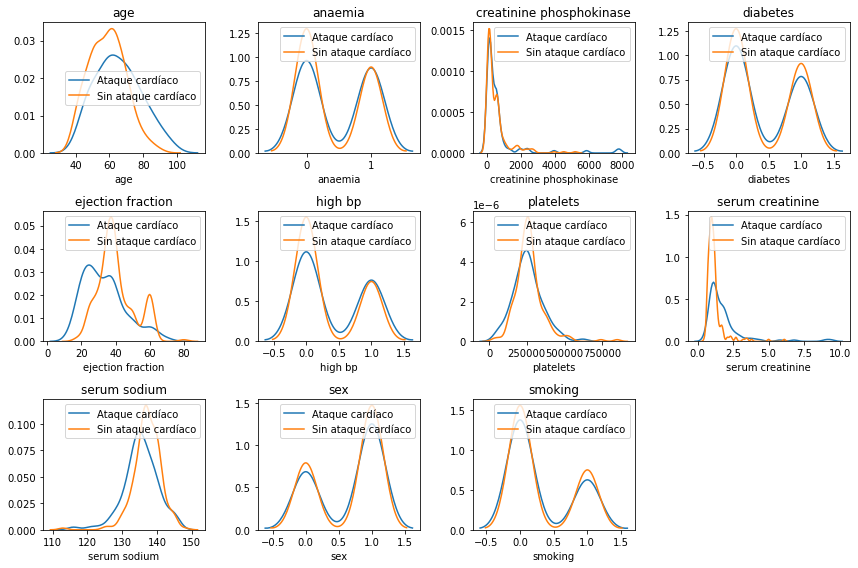

In [4]:
heart_attack = data[data['death'] == 1]
no_heart_attack = data[data['death'] == 0]

plt.figure(figsize=(12, 8))
for feature in data.columns[:-1]: 
    plt.subplot(3, 4, data.columns.get_loc(feature) + 1)
    sns.distplot(heart_attack[feature], label='Ataque cardíaco', hist=False, kde=True)
    sns.distplot(no_heart_attack[feature], label='Sin ataque cardíaco', hist=False, kde=True)
    plt.legend()
    plt.title(feature)

plt.tight_layout()
plt.show()

#### División de los sets  de entrenamiento

Para la comparación de los modelos, se divide la base de datos original en 3 set diferentes al variar la proporción de datos usado para el entrenamiento. Esto serán los datos que deberá usar más adelante

In [5]:
# Dividir los datos (X) y variable objetivo (y)
X = data.drop('death', axis=1)
y = data['death']

# Dividir los datos en conjuntos de entrenamiento y prueba
#Set #1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#Set #2
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.5, random_state=42)
#Set #3
X_train3, X_test3, y_train3, y_test3 = train_test_split(X, y, test_size=0.8, random_state=42)

### Creación del modelo de clasificación
En esta sección se creará el modelo que debe usar en todo el taller. Se entrenerá inicialmente con el primer set de datos (Set#1)

Precisión de Árbol de Decisión: 0.6333333333333333


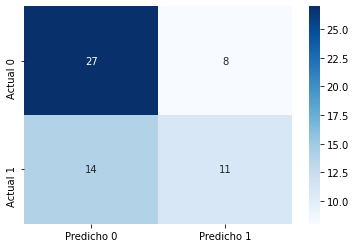

In [6]:
# Creación del modelo
model = DecisionTreeClassifier()

#Entrenamiento del modelo
model.fit(X_train, y_train)

#Predicciones con el conjunto de prueba
y_pred = model.predict(X_test)

#Métricas de desempeño
accuracy = accuracy_score(y_test, y_pred)
print("Precisión de Árbol de Decisión:", accuracy)

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Predicho 0', 'Predicho 1'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm_df, annot=True, cmap='Blues', fmt='g')

Ahora debe entrenar el modelo con los sets de datos #2 y #3 definidos anteriormente

Precisión de Árbol de Decisión: 0.6133333333333333


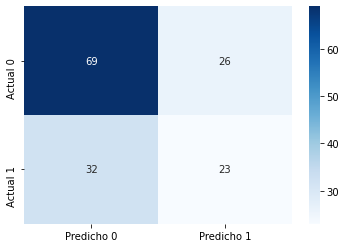

In [9]:
#=====================================================================
#COMPLETAR============================================================
#
#Ayuda:Guíese por el ejemplo dado con el set #1, 
#Entrene el modelo con el set #2 y obtenga las métricas de desempeño

# your code here
# Creación del modelo
model_2 = DecisionTreeClassifier()

#Entrenamiento del modelo
model_2.fit(X_train2, y_train2)

#Predicciones con el conjunto de prueba
y_pred2 = model_2.predict(X_test2)

#Métricas de desempeño
accuracy = accuracy_score(y_test2, y_pred2)
print("Precisión de Árbol de Decisión:", accuracy)

cm = confusion_matrix(y_test2, y_pred2)
cm_df = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Predicho 0', 'Predicho 1'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm_df, annot=True, cmap='Blues', fmt='g')
#=====================================================================


In [10]:
assert accuracy <0.66, 'Revise el entrenamiento y prueba del modelo'


Precisión de Árbol de Decisión: 0.6625


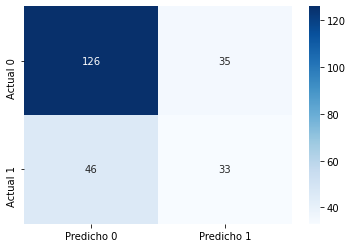

In [11]:
#=====================================================================
#COMPLETAR============================================================
#
#Ayuda:Guíese por el ejemplo dado con el set #1, 
#Entrene el modelo con el set #3 y obtenga las métricas de desempeño

# your code here
# Creación del modelo
model_3 = DecisionTreeClassifier()

#Entrenamiento del modelo
model_3.fit(X_train3, y_train3)

#Predicciones con el conjunto de prueba
y_pred3 = model_3.predict(X_test3)

#Métricas de desempeño
accuracy = accuracy_score(y_test3, y_pred3)
print("Precisión de Árbol de Decisión:", accuracy)

cm = confusion_matrix(y_test3, y_pred3)
cm_df = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Predicho 0', 'Predicho 1'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm_df, annot=True, cmap='Blues', fmt='g')
#=====================================================================


In [12]:
assert accuracy <0.67, 'Revise el entrenamiento y prueba del modelo'

Ahora vamos a visualizar la proporción de pacientes que tiene riesgo o no de padecer un infarto según la base de datos obtenida. 

0    203
1     96
Name: death, dtype: int64


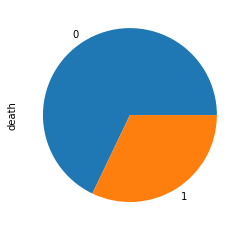

In [13]:
#Conteo para revisar balance de la base de datos
y.value_counts().plot(kind='pie')
print(y.value_counts())

Podemos ver que hay una clase mayoritaria correspondiente a los pacientes que no sufrirán infartos. Esto se conoce como desbalance de clases en un problema de clasifiación. (Este tema será abordado más adeltante en el curso). Una problemática de usar una base desbalanceada es que se el modelo será entrenado con sesgos. En este caso, el modelo clasificará correctamente los pacientes sin riesgos pero tendrá dificultades para identificar los pacientes con riesgo. A conntinuación se realiza el balance de las clases.

1    203
0    203
Name: death, dtype: int64


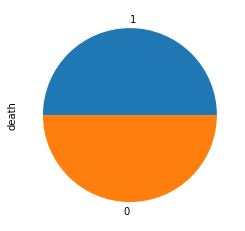

In [14]:
#Balanceo de datos empleando oversampling
smote = SMOTE(random_state=42)
X_train_over, y_train_over = smote.fit_resample(X, y)

#Visualización de la proporción de clases en los datos de entrenamiento
y_train_over.value_counts().plot(kind='pie')
print(y_train_over.value_counts())

A partir de esta nueva base de datos se deberán obtener de nuevos 3 sets de datos para entrenamiento y prueba para el posterior entrenamiento del modelo ya creado.

In [15]:
# Dividir los datos en conjuntos de entrenamiento y prueba
#Set #1
X_train1, X_test, y_train1, y_test = train_test_split(X_train_over, y_train_over, test_size=0.2, random_state=42)

#=====================================================================
#COMPLETAR============================================================
#
#Set #2
# your code here
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_train_over, y_train_over, test_size=0.5, random_state=42)

#Set #3
# your code here
X_train3, X_test3, y_train3, y_test3 = train_test_split(X_train_over, y_train_over, test_size=0.8, random_state=42)
#=====================================================================


Precisión de Árbol de Decisión: 0.8170731707317073


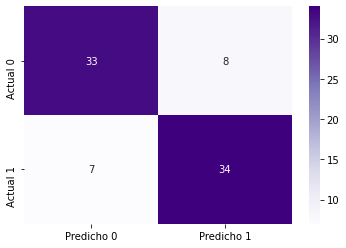

In [16]:
#=====================================================================
#COMPLETAR============================================================
#
#Ayuda:Guíese por el ejemplo inicial, 
#Entrene el modelo con el set #1 y obtenga las métricas de desempeño

# your code here
# Creación del modelo
model = DecisionTreeClassifier()

#Entrenamiento del modelo
model.fit(X_train1, y_train1)

#Predicciones con el conjunto de prueba
y_pred1 = model.predict(X_test)

#Métricas de desempeño
accuracy = accuracy_score(y_test, y_pred1)
print("Precisión de Árbol de Decisión:", accuracy)

cm = confusion_matrix(y_test, y_pred1)
cm_df = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Predicho 0', 'Predicho 1'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm_df, annot=True, cmap='Purples', fmt='g')
#=====================================================================


In [17]:
assert accuracy <0.82, 'Revise el entrenamiento y prueba del modelo'

Precisión de Árbol de Decisión: 0.7487684729064039


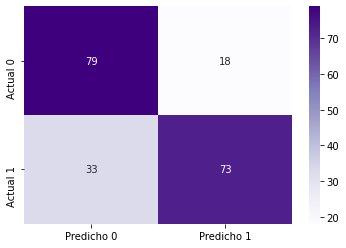

In [18]:
#=====================================================================
#COMPLETAR============================================================
#
#Ayuda:Guíese por el ejemplo inicial, 
#Entrene el modelo con el set #2 y obtenga las métricas de desempeño

# your code here
# Creación del modelo
model = DecisionTreeClassifier()

#Entrenamiento del modelo
model.fit(X_train2, y_train2)

#Predicciones con el conjunto de prueba
y_pred2 = model.predict(X_test2)

#Métricas de desempeño
accuracy = accuracy_score(y_test2, y_pred2)
print("Precisión de Árbol de Decisión:", accuracy)

cm = confusion_matrix(y_test2, y_pred2)
cm_df = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Predicho 0', 'Predicho 1'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm_df, annot=True, cmap='Purples', fmt='g')
#=====================================================================


In [19]:
assert accuracy <0.79, 'Revise el entrenamiento y prueba del modelo'

Precisión de Árbol de Decisión: 0.6184615384615385


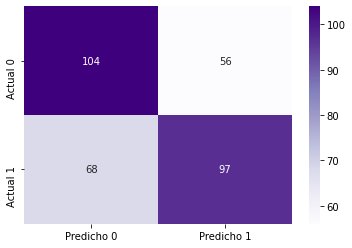

In [20]:
#=====================================================================
#COMPLETAR============================================================
#
#Ayuda:Guíese por el ejemplo inicial, 
#Entrene el modelo con el set #3 y obtenga las métricas de desempeño

# your code here
# Creación del modelo
model = DecisionTreeClassifier()

#Entrenamiento del modelo
model.fit(X_train3, y_train3)

#Predicciones con el conjunto de prueba
y_pred3 = model.predict(X_test3)

#Métricas de desempeño
accuracy = accuracy_score(y_test3, y_pred3)
print("Precisión de Árbol de Decisión:", accuracy)

cm = confusion_matrix(y_test3, y_pred3)
cm_df = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Predicho 0', 'Predicho 1'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm_df, annot=True, cmap='Purples', fmt='g')
#=====================================================================


In [21]:
assert accuracy <0.65, 'Revise el entrenamiento y prueba del modelo'

### Preguntas de análisis

¿El desempeño de los modelos es significativamente diferente? Comente a partir de los resultados de la matriz de confusión.

¿Cómo se afecta el desempeño del modelo al ser entrenado con diferentes proporciones de datos de entrenamiento y prueba?

¿Cómo cambia el desempeño del modelo al ser entrenado antes y después de balancear la base de datos? Comente como esto podría afectar la implementación de este modelo en el cotexto médico del caso aplicado

**Respuesta:**

YOUR ANSWER HERE:

* 1. Sí. al balancear los datos, el modelo mejora notablemente en las divisiones donde hay más datos de entrenamiento, como por ejemplo;
    * Cuando hacemos la división 80% entrenamiento y 20% test obtenemos un accuracy sin balancear los datos de 0.6333 (63%) y cuando balanceamos los datos haciendo la misma división obtuvimos un accuracy de 0.8171 (81.71%), lo que representa un incremento de aproximadamente 18 puntos porcentuales.
    
   Sin embargo, cuando realizamos la comparación del set 3 donde realizamos una división de 20% entrenamiento y 80% test sin balancear los datos, obtuvimos un accuracy de 0.6625 (66.25%) y cuando balancemos los datos con la misma división, obtuvimos un accuracy de 0.61185 (61.85%), el desempeño cayó ligeramente. Lo que nos indica que muy pocos datos de entrenamiento afectan negativamente el rendimiento del modelo, incluso si los datos estan balanceados.

* 2. En ambos casos (balanceado y no balanceado), el mejor desempeño se obtuvo con más datos de entrenamiento (80/20). A medida que disminuye el porcentaje de datos para entrenar, el modelo pierde capacidad de generalización y baja el accuracy, como observamos en la división del set 3, la caída fue más drástica en el set balanceado con 20% de entrenamiento, mostrando que el balanceo no compensa la falta de ejemplos para aprender patrones.

* 3. Antes de realizar el balanceo de los datos, el modelo estaba sesgado hacia la clase mayoritaria que corresponde a los pacientes que no mueren por insuficiencia cardiaca. Lo que nos puede llevar a muchos falsos negativos. Cuando realizamos el balance de los datos, el modelo reconoce mejor la clases minoritaria que corresponde a los pacientes que mueren por insuficiencia cardiaca, lo que nos reduce los falsos negativos y mejora la detección de casos de riesgo.

     En cuanto al contexto médico, un falso negativo puede significar no tomar medidas preventivas a tiempo por lo que la vida del paciente estaria en riesgo. Por otro lado, si tenemos un falso positivo implicaria más pruebas y seguimiento al paciente, se afectaria el paciente pero no habría un riesgo directo. Por lo tanto, es importante balancear los datos para priorizar la detección temprana de insuficiencia cardiaca, aunque puedan aumentar los falsos positivos. 